In [5]:
import polars as pl
import numpy as np
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import os
from pathlib import Path
import sys
sys.path.insert(1, os.path.abspath(".."))
os.chdir(os.path.abspath('..')) # Change the workdir to the parent folder

In [32]:
from src.configs.dataconfig import input_output_config
from src.configs.aggregator import feature_config
from src.configs.sirscalculator import sirs_config 
from src.utils.utils import load_df

In [36]:
idx = 0
feature_config.selected[idx].value.split('_')[-2], feature_config.selected[idx].value.split('_')[-1][:-1]

('temp', '8')

In [33]:
sirs_config

SIRSConfig(encounter_col='EncounterEpicCsn', event_dt_col='Event_DateTime', event_name_col='Event_Name', grouper_col='Event_Grouper', type_col='Type', val_col='NumericValue', raw_val_col='Value', BASELINE_CREATININE='Baseline_Creatinine', BASELINE_SBP='Baseline_SBP', BASELINE_RESP_RATE='Baseline_RespiratoryRate', BASELINE_PULSE_RATE='Baseline_PulseRate', BASELINE_PLATELETS='Baseline_Platelets', BASELINE_BILIRUBIN='Baseline_Bilirubin', BASELINE_eGFR='Baseline_eGFR', BASELINE_WBC='Baseline_WBC', temp_grouper_val='Temperature', hr_grouper_val='Pulse', resp_grouper_val='Respirations', wbc_grouper_val='WBC', temp_flag_col='Temp_Abnormal_Flag', hr_flag_col='HR_High_Flag', resp_flag_col='Resp_Rate_High_Flag', wbc_flag_col='WBC_Abnormal_Flag', temp_lower_threshold=96.8, temp_upper_threshold=100.4, hr_upper_threshold=90, resp_upper_threshold=20, wbc_lower_threshold=4, wbc_upper_threshold=12, sirs_score_col='sirs_score')

In [7]:
input_output_config

DataInputOutputConfig(data_path='/work/InternalMedicine/s223850/Sepsis-data/data/raw_data_phase2_v2', output_path='/work/InternalMedicine/s223850/Sepsis-data/data/output/raw_data_phase2_v2', logger_dir='./logs', input_file_names=InputFileNames(ENCOUNTER_BASELINE_SCORES='Encounter Table with Baseline Values - Mar 2025 - Feb 2026 - 4.13.26 v2.csv', FLOWSHEETS='Flowsheets - Mar 2025 - Feb 2026 - 4.9.26.csv', LABS='Lab Results - Mar 2025 - Feb 2026 - 4.8.26.csv', MEDS='Med Admin - Mar 2025 - Feb 2026 - 4.8.26.csv', PROCEDURES='Procedure Orders - Mar 2025 - Feb 2026 - 4.9.26.csv', DIAGNOSIS='Diagnoses - 3.9.26.csv'), convert_bp_to_sbp=True)

In [ ]:
df_all = load_df(input_output_config.output_path, "df_all.parquet")
df_sirs = load_df(input_output_config.output_path, "df_sirs.parquet")

In [38]:
total_expr = pl.lit(None)

total_expr = (
	pl.when(
		pl.col("Event_Grouper") == "Temperature"
	).then(
        pl.lit(8)
	).otherwise(total_expr)
)

total_expr = (
    pl.when(
        pl.col("Event_Grouper") == "Pulse"
	).then(
        pl.lit(8)
	).otherwise(total_expr)
)

total_expr = (
    pl.when(
		pl.col("Event_Grouper") == "Respirations"
	).then(
		pl.lit(8)
	).otherwise(total_expr)
)

total_expr = (
    pl.when(
		pl.col("Event_Grouper") == "Blood Pressure"
	).then(
		pl.lit(8)
	).otherwise(total_expr)
)

total_expr = (
    pl.when(
		pl.col("Event_Grouper") == "WBC"
	).then(
		pl.lit(12)
	).otherwise(total_expr)
)

In [50]:
df_sirs.sort(by=['EncounterEpicCsn', 'Event_DateTime']).with_columns(
	total_expr.alias("Total_Flag_Count"),
    pl.when(
        pl.col("NumericValue").is_not_null()
	).then(
        pl.col("Event_DateTime")
	).otherwise(
        None
	).alias("_origin_ts")
).with_columns(
    pl.col("NumericValue").forward_fill().over("EncounterEpicCsn", "Event_Grouper").alias("_val_ffill"),
    pl.col("_origin_ts").forward_fill().over("EncounterEpicCsn", "Event_Grouper").alias("_origin_ts_ffill"),
).with_columns(
	(pl.col("Event_DateTime")-pl.col("_origin_ts_ffill")).dt.total_hours(fractional=True).alias("Hours_Since_Origin"),
    pl.when(
        (pl.col("Event_DateTime")-pl.col("_origin_ts_ffill")).dt.total_hours(fractional=True) <= pl.col("Total_Flag_Count")
	).then(
        pl.col("_val_ffill")
	).otherwise(
		None
	).alias("NumericValue")
).select(
    "EncounterEpicCsn", "Event_DateTime", "Event_Grouper", "NumericValue", "Total_Flag_Count", "_origin_ts_ffill", "Hours_Since_Origin"
).filter(
    (pl.col("Event_Grouper") == "Pulse")&
    (pl.col("Event_DateTime") !=  pl.col("_origin_ts_ffill"))
).to_pandas().head(30)

,EncounterEpicCsn,Event_DateTime,Event_Grouper,NumericValue,Total_Flag_Count,_origin_ts_ffill,Hours_Since_Origin
0,699476058,2024-04-30 21:57:00,Pulse,NaN,8,2024-04-30 06:15:00,15.700000
1,699476058,2024-05-06 12:58:00,Pulse,95.0,8,2024-05-06 12:16:00,0.700000
2,699476058,2024-06-17 09:10:00,Pulse,68.0,8,2024-06-17 08:00:00,1.166667
3,699476058,2024-07-13 19:23:00,Pulse,100.0,8,2024-07-13 19:15:00,0.133333
4,699476058,2024-08-19 10:50:00,Pulse,93.0,8,2024-08-19 09:00:00,1.833333
5,699476058,2024-08-25 10:30:00,Pulse,87.0,8,2024-08-25 10:00:00,0.500000
6,699476058,2024-09-26 00:14:54,Pulse,93.0,8,2024-09-26 00:00:00,0.248333
7,699476058,2024-10-15 16:00:00,Pulse,82.0,8,2024-10-15 15:04:00,0.933333
8,699476058,2024-10-23 19:00:00,Pulse,82.0,8,2024-10-23 18:45:00,0.250000
9,699476058,2025-01-16 10:37:00,Pulse,101.0,8,2025-01-16 10:07:00,0.500000


In [5]:
df_all.filter(pl.col("Type")=="Flowsheet")['Event_Grouper'].unique().to_list()

['Arterial Blood Pressure Mean',
 'O2 Delivery Mechanical Ventilation',
 'Neurological Assessment',
 'Pulse',
 'O2 Flow Rate',
 'O2 Delivery Room Air',
 'Respiratory Assessment',
 'Urine Output',
 'Braden Scale',
 'O2 Delivery High-Flow',
 'Skin Assessment',
 'O2 Delivery Nasal Cannula',
 'Gastrointestinal Assessment',
 'Genitourinary Assessment',
 'Oxygen Delivery',
 'Blood Pressure',
 'BMI',
 'Glasgow Coma Score',
 'Respirations',
 'O2 Delivery Simple Face Mask',
 'Weight',
 'O2 Delivery Non-Rebreather Mask',
 'Vent off Documentation',
 'Vent On/Off',
 'Vent on Documentation',
 'Temperature',
 'Pain Scale',
 'Suspected Infection']

In [5]:
Event_Grouper_val = ""#"Temperature"

In [5]:
df_pulse = df_all.filter(
	(pl.col("Type") == "Flowsheet")&
	(pl.col("Event_Grouper") == Event_Grouper_val)
).sort(by=['EncounterEpicCsn', 'Event_DateTime'])\
.with_columns(
    pl.col("Event_DateTime").shift(1).over("EncounterEpicCsn").alias("perv_Event_DateTime")
)\
.with_columns(
    delta_time = (pl.col("Event_DateTime") - pl.col("perv_Event_DateTime")).over("EncounterEpicCsn").dt.total_hours(fractional=True)
).select(["EncounterEpicCsn", "NumericValue", "Event_DateTime"])
# .group_by("EncounterEpicCsn").agg(pl.col("NumericValue"), pl.col("delta_time"))

NameError: name 'Event_Grouper_val' is not defined

In [28]:
df_pulse['NumericValue'].null_count()/len(df_pulse)

0.0026170076090005156

In [29]:
MAX_ALLOWED = 8 #hours
df_pulse = df_pulse.with_columns(
    pl.when(
        pl.col("NumericValue").is_null()
	).then(
		None
	).otherwise(pl.col("Event_DateTime")).alias("Event_DateTime_nullable")
).with_columns(
    pl.col("NumericValue").forward_fill().over("EncounterEpicCsn").alias("ffill_value"),
	pl.col("Event_DateTime_nullable").forward_fill().over("EncounterEpicCsn").alias("ffill_Event_DateTime"),
    pl.col("NumericValue").backward_fill().over("EncounterEpicCsn").alias("bfill_value"),
	pl.col("Event_DateTime_nullable").backward_fill().over("EncounterEpicCsn").alias("bfill_Event_DateTime")
).with_columns(
	ffill_diff = (pl.col("Event_DateTime")-pl.col("ffill_Event_DateTime")).dt.total_hours(fractional=True),
	bfill_diff = (pl.col("Event_DateTime")-pl.col("bfill_Event_DateTime")).dt.total_hours(fractional=True)
).with_columns(
	pl.when(
        (pl.col('ffill_diff')>MAX_ALLOWED)&
        (pl.col('bfill_diff')>MAX_ALLOWED)
	).then(
        None
	).when(
        pl.col("ffill_diff")<pl.col("bfill_diff")
	).then(pl.col("ffill_value")).otherwise(pl.col("bfill_value")).alias("imputed_value")
)

In [30]:
df_pulse['imputed_value'].null_count()/len(df_pulse)

1.0555490212044719e-05

In [8]:
df_pulse.with_columns(
    pl.col("NumericValue").forward_fill().over("EncounterEpicCsn").alias("ffill_value"),
	pl.when(
        pl.col("NumericValue").is_null()
	).then(
        pl.col("Event_DateTime").forward_fill().over("EncounterEpicCsn")
	).otherwise(pl.col("Event_DateTime")).alias("ffill_Event_DateTime")
)

EncounterEpicCsn,NumericValue,Event_DateTime,ffill_value,ffill_Event_DateTime
i64,f64,datetime[μs],f64,datetime[μs]
699476058,94.0,2024-04-30 06:15:00,94.0,2024-04-30 06:15:00
699476058,null,2024-04-30 21:57:00,94.0,2024-04-30 21:57:00
699476058,92.0,2024-04-30 21:58:00,92.0,2024-04-30 21:58:00
699476058,92.0,2024-04-30 22:00:00,92.0,2024-04-30 22:00:00
699476058,93.0,2024-04-30 22:05:00,93.0,2024-04-30 22:05:00
…,…,…,…,…
747311714,64.0,2026-02-27 09:33:00,64.0,2026-02-27 09:33:00
747311714,67.0,2026-02-27 11:14:00,67.0,2026-02-27 11:14:00
747311714,66.0,2026-02-27 11:15:00,66.0,2026-02-27 11:15:00


In [13]:
lf = df_pulse.lazy().join_where(
    df_pulse.lazy(),
    (pl.col("Event_DateTime")-pl.col("Event_DateTime_right")).dt.total_hours(fractional=True)<=8,
    suffix="_right"
)

In [ ]:
df_pulse = lf.collect()

In [ ]:
# Break the kernel
# df_pulse.join(
#     df_pulse,
#     on="EncounterEpicCsn"
# ).filter(pl.col("delta_time") <= 8)


In [58]:
df_all.filter(
		# (pl.col("Type") == "Flowsheet")&
		# (pl.col("Event_Grouper") == "Blood Pressure")&
        # (pl.col("Value").is_not_null())&
        (pl.col("Value").str.contains("X;integrity"))
)['Event_Grouper'].unique()

Event_Grouper
str
"""Skin Assessment"""


------------

# Outlier detection
Implementation involves three layers:
1. Physiological bounds: Remove any value outside the physiological values
2. Velocity bounds: Remove any fast transitions that are physilogically impossible
3. Windowed statistical outlier detection algorithm: 

In [5]:
df_all.filter(
    pl.col("Event_Grouper") == "Blood Pressure"
)['Event_Name'].unique()

Event_Name
str
"""BLOOD PRESSURE"""


In [6]:
df_all = df_all.with_columns(
    pl.when(
        pl.col("Event_Grouper") == "Blood Pressure"
	).then(
        pl.col("Value").str.split('/').list.get(0).cast(pl.Float64, strict=False)
	).otherwise(
        pl.col("NumericValue")
	).alias("NumericValue")
)

In [8]:
cusum_params = {
    "Pulse":   {"threshold": 8.0,  "drift": 2.0},
    "Blood Pressure":  {"threshold": 10.0, "drift": 3.0},
    # "SpO2": {"threshold": 5.0,  "drift": 1.0},
    "Temperature": {"threshold": 0.8,  "drift": 0.1},
    "Respirations":   {"threshold": 5.0,  "drift": 1.0},
}

velocity_thresholds = pl.DataFrame([
    {"vital_type": "Pulse",   "max_velocity": 40.0},
    {"vital_type": "Blood Pressure",  "max_velocity": 50.0},
    # {"vital_type": "DBP",  "max_velocity": 40.0},
    # {"vital_type": "SpO2", "max_velocity": 30.0},
    {"vital_type": "Temperature", "max_velocity": 0.5},
    {"vital_type": "Respirations",   "max_velocity": 20.0},
    # {"vital_type": "MAP",  "max_velocity": 40.0},
])

bounds = {
    "Pulse":   {"min": 20,  "max": 250},
    # "Blood Pressure":  {"min": 30,  "max": 300},
    "Blood Pressure":  {"min": 40,  "max": 300},
    # "DBP":  {"min": 10,  "max": 200},
    # "SpO2": {"min": 20,  "max": 100},
    # "Temperature": {"min": 25.0,"max": 45.0}, # C
    # "Temperature": {"min": 28.0,"max": 43.0}, # C
    "Temperature": {"min": 82.4,"max": 109.4}, # F
    # "Respirations":   {"min": 2,   "max": 80},
    "Respirations":   {"min": 4,   "max": 60},
    # "MAP":  {"min": 20,  "max": 250},
}

In [9]:
df_all.filter(
    (pl.col("Event_Grouper") == "Blood Pressure")&
    (pl.col("NumericValue").is_not_null())
)['NumericValue'].sort()

NumericValue
f64
0.0
0.0
0.0
0.0
0.0
…
257.0
259.0
263.0


In [10]:
df_all.columns

['EncounterEpicCsn',
 'Event_DateTime',
 'Type',
 'Event_Grouper',
 'Event_Name',
 'NumericValue',
 'Value',
 'Flag',
 'PrimaryMrn',
 'EncounterEpicCsn_right',
 'AdmissionDateValue',
 'DischargeDateValue',
 'Arrival_Instant',
 'InpatientAdmissionInstant',
 'Admitted_from_ED',
 'PatientClass',
 'InpatientAdmissionPatientClass',
 'HospitalService',
 'LengthOfStayInDays',
 'AdmittingDepartment',
 'DischargeDepartment',
 'AdmissionType',
 'AdmissionSource',
 'AdmissionOrigin',
 'PrincipalProblem',
 'PrimaryCodedDiagnosis',
 'PrimaryCodedProcedureKey',
 'Death_Flag',
 'Original_POA_Condition',
 'Sepsis_Category',
 'Baseline_SBP',
 'Baseline_RespiratoryRate',
 'Baseline_PulseRate',
 'Baseline_Creatinine',
 'Baseline_Platelets',
 'Baseline_Bilirubin',
 'Baseline_eGFR',
 'Baseline_WBC',
 'First_Suspected_Infection_Time',
 'Suspected_Infection_Criteria_Met',
 'Cancer_Registry_YN',
 'HIV_Registry_YN',
 'Immunocrompromised_Registry_YN',
 'CKD_Dialysis_Registry_YN',
 'Solid_Organ_Transplant_Regist

In [11]:
for vital, params in bounds.items():
	df_vital = df_all.filter(
		(pl.col("Event_Grouper") == vital)&
		(
			(pl.col("NumericValue") < params['min'])|
			(pl.col("NumericValue") > params['max'])
		)
	)
	
	print(f"{vital}: has {df_vital.shape[0]} physiologically implausible values over {df_vital['EncounterEpicCsn'].n_unique()} encounters")

Pulse: has 682 physiologically implausible values over 373 encounters
Blood Pressure: has 83 physiologically implausible values over 55 encounters
Temperature: has 98 physiologically implausible values over 90 encounters
Respirations: has 5646 physiologically implausible values over 644 encounters


In [12]:
config = pl.DataFrame({
    "Event_Grouper": [
        "Pulse",
        # "Blood Pressure Systolic",
        "Blood Pressure",
        # "Respiratory Rate",
        "Respirations",
        "Temperature",  # assuming Celsius
    ],
    "max_velocity_per_min": [60.0, 60.0, 20.0, 0.06],
    "max_absolute_step":    [150.0, 100.0, 30.0, 5.4],
    "validity_window_min":  [30, 30, 30, 60],
})

In [13]:
config = pl.DataFrame({
    "Event_Grouper": [
        "Pulse",
        # "Blood Pressure Systolic",
        "Blood Pressure",
        # "Respiratory Rate",
        "Respirations",
        "Temperature",  # assuming Celsius
    ],
    "max_velocity_per_min": [60.0, 60.0, 20.0, 0.06],
    "max_absolute_step":    [150.0, 100.0, 30.0, 5.4],
    "validity_window_min":  [30, 30, 30, 60],
	"upper_physiological_bound": [250.0, 300.0, 60.0, 45.0],
	"lower_physiological_bound": [20.0, 40.0, 4.0, 25.0]
})

df_all.select(
    "EncounterEpicCsn",
    "Event_Grouper",
    "Event_DateTime",
	"NumericValue"
).filter(
    pl.col("Event_Grouper").is_in(config['Event_Grouper'].to_list())
).drop_nulls(
).join(
    config,
    on="Event_Grouper",
    how='left',
).sort(
    by=["EncounterEpicCsn", "Event_DateTime"]
).with_columns(
    pl.col("Event_DateTime").shift(1).over(["EncounterEpicCsn", "Event_Grouper"]).alias("prev_Event_DateTime"),
    pl.col("NumericValue").shift(1).over(["EncounterEpicCsn", "Event_Grouper"]).alias("prev_NumericValue"),
).with_columns(
	delta_time  = (pl.col("Event_DateTime") - pl.col("prev_Event_DateTime")).dt.total_minutes(fractional=True),
	delta_value = (pl.col("NumericValue") - pl.col("prev_NumericValue"))
).with_columns(
    velocity = pl.col("delta_value")/(pl.col("delta_time")+1e-6)
).drop_nulls(
    subset=['velocity']
).with_columns(
	abs_step = pl.col("delta_value").abs(),
    abs_velocity = pl.col("velocity").abs(),
    within_window = pl.col("delta_time") <= pl.col("validity_window_min")
).with_columns(
    velocity_violation = pl.col("within_window") & (pl.col("abs_velocity") > pl.col("max_velocity_per_min")),
    step_violation     = pl.col("within_window") & (pl.col("abs_step")     > pl.col("max_absolute_step")),
).with_columns(
    is_transition_outlier = pl.col("velocity_violation") | pl.col("step_violation"),
).with_columns(
    pl.when(pl.col("is_transition_outlier")).then(None).otherwise(pl.col("NumericValue")).alias("cleaned_value")
).with_columns(
    rolling_median = pl.col("cleaned_value").rolling_median_by(
        by='Event_DateTime',
		window_size="5h",
		closed='left'
	).over("EncounterEpicCsn", "Event_Grouper"),
    rolling_std = pl.col("cleaned_value").rolling_std_by(
        by='Event_DateTime',
		window_size="5h",
		closed='left'
	).over("EncounterEpicCsn", "Event_Grouper"),

).with_columns(
    rolling_std_floored = pl.max_horizontal(pl.col("rolling_std"), pl.lit(4.0))
).with_columns(
    z_score = (pl.col("NumericValue")-pl.col("rolling_median"))/pl.col("rolling_std_floored")
).with_columns(
    is_statistical_outlier = pl.col("z_score").abs() > 4.0
)


InvalidOperationError: 'Expr.rolling_*_by(...)' not yet supported for series with null values, consider using 'DataFrame.rolling' or 'Expr.rolling'

In [19]:
config = pl.DataFrame({
    "Event_Grouper": [
        "Pulse",
        # "Blood Pressure Systolic",
        "Blood Pressure",
        # "Respiratory Rate",
        "Respirations",
        "Temperature",  # assuming Celsius
    ],
    "max_velocity_per_min": [60.0, 60.0, 20.0, 0.06],
    "max_absolute_step":    [150.0, 100.0, 30.0, 5.4],
    "validity_window_min":  [30, 30, 30, 60],
	"upper_physiological_bound": [250.0, 300.0, 60.0, 45.0],
	"lower_physiological_bound": [20.0, 40.0, 4.0, 25.0]
})

df_with_conds = df_all.select(
    "EncounterEpicCsn",
    "Event_Grouper",
    "Event_DateTime",
	"NumericValue"
).filter(
    pl.col("Event_Grouper").is_in(config['Event_Grouper'].to_list())
).drop_nulls(
).join(
    config,
    on="Event_Grouper",
    how='left',
).sort(
    by=["EncounterEpicCsn", "Event_DateTime"]
).with_columns(
    pl.col("Event_DateTime").shift(1).over(["EncounterEpicCsn", "Event_Grouper"]).alias("prev_Event_DateTime"),
    pl.col("NumericValue").shift(1).over(["EncounterEpicCsn", "Event_Grouper"]).alias("prev_NumericValue"),
).with_columns(
	delta_time  = (pl.col("Event_DateTime") - pl.col("prev_Event_DateTime")).dt.total_minutes(fractional=True),
	delta_value = (pl.col("NumericValue") - pl.col("prev_NumericValue"))
).with_columns(
    velocity = pl.col("delta_value")/(pl.col("delta_time")+1e-6)
).drop_nulls(
    subset=['velocity']
).with_columns(
	abs_step = pl.col("delta_value").abs(),
    abs_velocity = pl.col("velocity").abs(),
    within_window = pl.col("delta_time") <= pl.col("validity_window_min")
).with_columns(
    velocity_violation = pl.col("within_window") & (pl.col("abs_velocity") > pl.col("max_velocity_per_min")),
    step_violation     = pl.col("within_window") & (pl.col("abs_step")     > pl.col("max_absolute_step")),
).with_columns(
    is_transition_outlier = pl.col("velocity_violation") | pl.col("step_violation"),
)

df_clean_pulse = df_with_conds.filter(
	 (pl.col("Event_Grouper") == "Pulse")&
    # ~(pl.col("is_transition_outlier")|pl.col("is_range_outlier"))
    ~pl.col("is_transition_outlier")
).sort(
    by=["EncounterEpicCsn", "Event_DateTime"]
)


df_clean_pulse = df_clean_pulse.with_columns(
    rolling_median = pl.col("NumericValue").rolling_median_by(
        by='Event_DateTime',
		window_size="5h",
		closed='left'
	).over("EncounterEpicCsn", "Event_Grouper"),
    rolling_std = pl.col("NumericValue").rolling_std_by(
        by='Event_DateTime',
		window_size="5h",
		closed='left'
	).over("EncounterEpicCsn", "Event_Grouper"),

).with_columns(
    rolling_std_floored = pl.max_horizontal(pl.col("rolling_std"), pl.lit(4.0))
).with_columns(
    z_score = (pl.col("NumericValue")-pl.col("rolling_median"))/pl.col("rolling_std_floored")
).with_columns(
    is_statistical_outlier = pl.col("z_score").abs() > 4.0
)

df_with_conds_pulse = df_with_conds.join(
    df_clean_pulse.select("EncounterEpicCsn", "Event_Grouper", "Event_DateTime",  "rolling_median", "rolling_std_floored", 'z_score', "is_statistical_outlier"),
    on=['EncounterEpicCsn', "Event_DateTime", "Event_Grouper"],
    how='left',
    suffix = '_ll'
)

In [52]:
config

Event_Grouper,max_velocity_per_min,max_absolute_step,validity_window_min,upper_physiological_bound,lower_physiological_bound,rolling_std_floor,rolling_window,z_score_threshold
str,f64,f64,i64,f64,f64,f64,str,f64
"""Pulse""",60.0,150.0,30,250.0,20.0,4.0,"""5h""",4.0
"""Blood Pressure""",60.0,100.0,30,300.0,40.0,5.0,"""5h""",4.0
"""Respirations""",20.0,30.0,30,60.0,4.0,2.0,"""5h""",4.0
"""Temperature""",0.108,9.72,60,113.0,77.0,0.9,"""5h""",4.0


In [33]:
config = pl.DataFrame([
    {
        "Event_Grouper":            "Pulse",
        "max_velocity_per_min":     60.0,
        "max_absolute_step":        150.0,
        "validity_window_min":      30,
        "upper_physiological_bound": 250.0,
        "lower_physiological_bound": 20.0,
        "rolling_std_floor":        4.0,
        "rolling_window":           "5h",
        "z_score_threshold":        4.0,
    },
    {
        "Event_Grouper":            "Blood Pressure",
        "max_velocity_per_min":     60.0,
        "max_absolute_step":        100.0,
        "validity_window_min":      30,
        "upper_physiological_bound": 300.0,
        "lower_physiological_bound": 40.0,
        "rolling_std_floor":        5.0,
        "rolling_window":           "5h",
        "z_score_threshold":        4.0,
    },
    {
        "Event_Grouper":            "Respirations",
        "max_velocity_per_min":     20.0,
        "max_absolute_step":        30.0,
        "validity_window_min":      30,
        "upper_physiological_bound": 60.0,
        "lower_physiological_bound": 4.0,
        "rolling_std_floor":        2.0,
        "rolling_window":           "5h",
        "z_score_threshold":        4.0,
    },
    {
        "Event_Grouper":            "Temperature",          # ← Now in Fahrenheit
        "max_velocity_per_min":     0.108,                  # 0.06 °C/min × 1.8
        "max_absolute_step":        9.72,                   # 5.4 °C × 1.8
        "validity_window_min":      60,
        "upper_physiological_bound": 113.0,                 # 45.0 °C → 113.0 °F
        "lower_physiological_bound": 77.0,                  # 25.0 °C → 77.0 °F
        "rolling_std_floor":        0.9,                    # 0.5 °C × 1.8
        "rolling_window":           "5h",
        "z_score_threshold":        4.0,
    }
])

df_base = (
    df_all
    .select(
        "EncounterEpicCsn",
        "Event_Grouper",
        "Event_DateTime",
        "NumericValue",
		"Value"
	).drop_nulls()
	.filter(pl.col("Event_Grouper").is_in(config['Event_Grouper'].to_list()))
	.join(config, on="Event_Grouper", how='left')
	.sort(by=["EncounterEpicCsn", "Event_Grouper", "Event_DateTime"])
)
df_base

EncounterEpicCsn,Event_Grouper,Event_DateTime,NumericValue,Value,max_velocity_per_min,max_absolute_step,validity_window_min,upper_physiological_bound,lower_physiological_bound,rolling_std_floor,rolling_window,z_score_threshold
i64,str,datetime[μs],f64,str,f64,f64,i64,f64,f64,f64,str,f64
699476058,"""Blood Pressure""",2024-04-30 06:15:00,103.0,"""103/63""",60.0,100.0,30,300.0,40.0,5.0,"""5h""",4.0
699476058,"""Blood Pressure""",2024-05-03 02:00:00,123.0,"""123/75""",60.0,100.0,30,300.0,40.0,5.0,"""5h""",4.0
699476058,"""Blood Pressure""",2024-05-03 10:03:00,135.0,"""135/67""",60.0,100.0,30,300.0,40.0,5.0,"""5h""",4.0
699476058,"""Blood Pressure""",2024-05-06 12:16:00,105.0,"""105/43""",60.0,100.0,30,300.0,40.0,5.0,"""5h""",4.0
699476058,"""Blood Pressure""",2024-05-12 22:00:00,105.0,"""105/68""",60.0,100.0,30,300.0,40.0,5.0,"""5h""",4.0
…,…,…,…,…,…,…,…,…,…,…,…,…
747311714,"""Temperature""",2026-02-27 01:00:00,98.5,"""98.5""",0.108,9.72,60,113.0,77.0,0.9,"""5h""",4.0
747311714,"""Temperature""",2026-02-27 03:07:00,99.1,"""99.1""",0.108,9.72,60,113.0,77.0,0.9,"""5h""",4.0
747311714,"""Temperature""",2026-02-27 05:00:00,99.4,"""99.4""",0.108,9.72,60,113.0,77.0,0.9,"""5h""",4.0


In [51]:
df_physio_range = (
    df_base.filter(
        (pl.col("NumericValue") >= pl.col("lower_physiological_bound"))&
        (pl.col("NumericValue") <= pl.col("upper_physiological_bound"))
	)
)
df_physio_outliers = (
    df_base.filter(
        (pl.col("NumericValue") < pl.col("lower_physiological_bound"))|
        (pl.col("NumericValue") > pl.col("upper_physiological_bound"))
	)
)

df_physio = (
    df_base.with_columns(pl.when(
        (pl.col("NumericValue") < pl.col("lower_physiological_bound"))|
        (pl.col("NumericValue") > pl.col("upper_physiological_bound"))
	).then(
        True
	).otherwise(
        False
	).alias("is_physio_outlier")
	)
)

# Show outlier fraction by Event_Grouper
# df_physio_outliers.group_by("Event_Grouper").agg(pl.len().alias('count')).join(
#     df_all.group_by("Event_Grouper").agg(pl.len().alias("total_count")),
#     on="Event_Grouper",
# ).with_columns(
#     (pl.col("count")/pl.col("total_count")).alias('outlier_fraction')
# ).sort(by='outlier_fraction', descending=True)


# Show outlier fraction by Encounter
# df_physio_outliers.group_by("EncounterEpicCsn").agg(pl.len().alias('count')).join(
# 	df_all.group_by("EncounterEpicCsn").agg(pl.len().alias("total_count")),
#     on="EncounterEpicCsn",
# ).with_columns(
#     (pl.col("count")/pl.col("total_count")).alias('outlier_fraction')
# ).sort(by='outlier_fraction', descending=True)

# 
# sns.barplot(df_physio_outliers.group_by(pl.col("Event_DateTime").dt.hour()).agg(pl.len().alias('count')).to_pandas(), x="Event_DateTime", y="count")
# sns.barplot(df_physio_outliers.group_by(pl.col("Event_DateTime").dt.weekday()).agg(pl.len().alias('count')).to_pandas(), x="Event_DateTime", y="count")
# df_physio_range

EVENT_GROUPER_OF_INTEREST = "Pulse"
ENCOUNTER_SAMPLE = 699476058
df_sample = df_physio.filter(pl.col("is_physio_outlier")).select(
    "EncounterEpicCsn", 
    "Event_Grouper",
	"Event_DateTime",
	"NumericValue",
).sort(by=["EncounterEpicCsn", "Event_Grouper", "Event_DateTime"]).join(
    df_physio,
	on=["EncounterEpicCsn", "Event_Grouper"],
	how='right'
).filter(
    (pl.col("Event_DateTime") >= pl.col("Event_DateTime_right") - pl.duration(hours=6)) &
    (pl.col("Event_DateTime") <= pl.col("Event_DateTime_right") + pl.duration(hours=6)) &
	(pl.col("Event_Grouper") == EVENT_GROUPER_OF_INTEREST)
).sort(by=["EncounterEpicCsn", "Event_Grouper", "Event_DateTime_right"])\
    .filter(pl.col("EncounterEpicCsn") == ENCOUNTER_SAMPLE)\
    .with_columns(
        pl.col("Value").cast(pl.Float64).alias("NumVal")
	)
df_sample
# fig, axes = plt.subplots(1, 2, figsize=(12, 6))
# sns.kdeplot(df_sample.to_pandas(), x="NumVal", hue="is_physio_outlier", fill=True, ax=axes[0])
# sns.histplot(df_sample.to_pandas(), x="NumVal", hue="is_physio_outlier", bins=128, fill=True, ax=axes[1])

Event_DateTime,NumericValue,EncounterEpicCsn,Event_Grouper,Event_DateTime_right,NumericValue_right,Value,max_velocity_per_min,max_absolute_step,validity_window_min,upper_physiological_bound,lower_physiological_bound,rolling_std_floor,rolling_window,z_score_threshold,is_physio_outlier,NumVal
datetime[μs],f64,i64,str,datetime[μs],f64,str,f64,f64,i64,f64,f64,f64,str,f64,bool,f64
2024-09-26 00:14:54,0.0,699476058,"""Pulse""",2024-09-25 18:15:00,85.0,"""85""",60.0,150.0,30,250.0,20.0,4.0,"""5h""",4.0,false,85.0
2024-09-26 00:14:54,0.0,699476058,"""Pulse""",2024-09-25 18:30:00,83.0,"""83""",60.0,150.0,30,250.0,20.0,4.0,"""5h""",4.0,false,83.0
2024-09-26 00:14:54,0.0,699476058,"""Pulse""",2024-09-25 18:36:00,82.0,"""82""",60.0,150.0,30,250.0,20.0,4.0,"""5h""",4.0,false,82.0
2024-09-26 00:14:54,0.0,699476058,"""Pulse""",2024-09-25 18:45:00,80.0,"""80""",60.0,150.0,30,250.0,20.0,4.0,"""5h""",4.0,false,80.0
2024-09-26 00:14:54,0.0,699476058,"""Pulse""",2024-09-25 19:00:00,79.0,"""79""",60.0,150.0,30,250.0,20.0,4.0,"""5h""",4.0,false,79.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2025-10-31 15:18:00,0.0,699476058,"""Pulse""",2025-10-31 12:34:00,78.0,"""78""",60.0,150.0,30,250.0,20.0,4.0,"""5h""",4.0,false,78.0
2025-10-31 15:18:00,0.0,699476058,"""Pulse""",2025-10-31 13:00:00,71.0,"""71""",60.0,150.0,30,250.0,20.0,4.0,"""5h""",4.0,false,71.0
2025-10-31 15:18:00,0.0,699476058,"""Pulse""",2025-10-31 14:00:00,73.0,"""73""",60.0,150.0,30,250.0,20.0,4.0,"""5h""",4.0,false,73.0


In [32]:
df_sample

Event_DateTime,NumericValue,is_physio_outlier,EncounterEpicCsn,Event_Grouper,Event_DateTime_right,Value,NumVal
datetime[μs],f64,bool,i64,str,datetime[μs],str,f64
2024-09-26 00:14:54,0.0,true,699476058,"""Pulse""",2024-09-25 21:15:00,"""85""",85.0
2024-09-26 00:14:54,0.0,true,699476058,"""Pulse""",2024-09-25 21:30:00,"""86""",86.0
2024-09-26 00:14:54,0.0,true,699476058,"""Pulse""",2024-09-25 21:45:00,"""87""",87.0
2024-09-26 00:14:54,0.0,true,699476058,"""Pulse""",2024-09-25 22:00:00,"""89""",89.0
2024-09-26 00:14:54,0.0,true,699476058,"""Pulse""",2024-09-25 22:15:00,"""85""",85.0
…,…,…,…,…,…,…,…
2025-10-31 15:18:00,0.0,true,699476058,"""Pulse""",2025-10-31 12:34:00,"""78""",78.0
2025-10-31 15:18:00,0.0,true,699476058,"""Pulse""",2025-10-31 13:00:00,"""71""",71.0
2025-10-31 15:18:00,0.0,true,699476058,"""Pulse""",2025-10-31 14:00:00,"""73""",73.0


In [61]:
PARTITION_COLS = ["EncounterEpicCsn", "Event_Grouper"]
EPSILON_MINUTES = 1e-6
df_with_transition = (
    df_physio_range.with_columns(
        pl.col("Event_DateTime").shift(1).over(PARTITION_COLS).alias("prev_Event_DateTime"),
        pl.col("NumericValue").shift(1).over(PARTITION_COLS).alias("prev_NumericValue")
	) 
    .with_columns(
        delta_time=(
            (pl.col("Event_DateTime") - pl.col("prev_Event_DateTime"))
            .dt.total_minutes(fractional=True)
        ),
        delta_value=(pl.col("NumericValue") - pl.col("prev_NumericValue")),
    )
    .with_columns(
        velocity=pl.col("delta_value") / (pl.col("delta_time") + EPSILON_MINUTES),
    )
    .with_columns(
        abs_step=pl.col("delta_value").abs(),
        abs_velocity=pl.col("velocity").abs(),
        within_window=pl.col("delta_time") <= pl.col("validity_window_min"),
    )
	# Reconsider
	.with_columns(
		pl.when(
            pl.col("abs_velocity") >= 1/EPSILON_MINUTES
		).then(None).otherwise(pl.col("abs_velocity")).alias("abs_velocity")
	)
    .with_columns(
        velocity_violation=(
            pl.col("within_window") & (pl.col("abs_velocity") > pl.col("max_velocity_per_min"))
        ),
        step_violation=(
            pl.col("within_window") & (pl.col("abs_step") > pl.col("max_absolute_step"))
        ),
    )
    .with_columns(
        velocity_violation=pl.col("velocity_violation").fill_null(False),
        step_violation=pl.col("step_violation").fill_null(False),
    )
    .with_columns(
        is_transition_outlier=pl.col("velocity_violation") | pl.col("step_violation"),
    )
)
df_transition_outliers = df_with_transition.filter(pl.col("is_transition_outlier"))

# df_transition_outliers.group_by(pl.col("Event_DateTime").dt.weekday()).agg(pl.len().alias('count')).sort(by='count', descending=True)
# sns.barplot(df_transition_outliers.group_by(pl.col("Event_DateTime").dt.weekday()).agg(pl.len().alias('count')).sort(by='count', descending=True).to_pandas(), x='Event_DateTime', y='count')

# df_transition_outliers.group_by(
#     "Event_Grouper"
# ).agg(pl.len().alias('count')).join(
#     df_all.group_by("Event_Grouper").agg(pl.len().alias("total_count")),
# 	on="Event_Grouper",
# ).with_columns(
#     (pl.col("count")/pl.col("total_count")).alias('outlier_fraction')
# ).sort(by='outlier_fraction', descending=True)


# df_transition_outliers.group_by(
#     "EncounterEpicCsn"
# ).agg(pl.len().alias('count')).join(
#     df_all.group_by("EncounterEpicCsn").agg(pl.len().alias("total_count")),
# 	on="EncounterEpicCsn",
# ).with_columns(
#     (pl.col("count")/pl.col("total_count")).alias('outlier_fraction')
# ).sort(by='outlier_fraction', descending=True)


EVENT_GROUPER_OF_INTEREST = "Pulse"
ENCOUNTER_SAMPLE = 699476058
df_sample = df_with_transition.filter(pl.col("is_transition_outlier")).select(
    "EncounterEpicCsn", 
    "Event_Grouper",
	"Event_DateTime",
	"NumericValue",
).sort(by=["EncounterEpicCsn", "Event_Grouper", "Event_DateTime"]).join(
    df_with_transition,
	on=["EncounterEpicCsn", "Event_Grouper"],
	how='right'
).filter(
	# (pl.col("NumericValue") == 68.0) &
	(pl.col("Event_Grouper") == EVENT_GROUPER_OF_INTEREST) &
    (pl.col("Event_DateTime") >= pl.col("Event_DateTime_right") - pl.duration(hours=1)) &
    (pl.col("Event_DateTime") <= pl.col("Event_DateTime_right") + pl.duration(hours=1))
).sort(by=["EncounterEpicCsn", "Event_Grouper", "Event_DateTime_right"])\
    .with_columns(
        pl.col("Value").cast(pl.Float64).alias("NumVal")
	).filter(pl.col("EncounterEpicCsn") == ENCOUNTER_SAMPLE)
df_sample.to_pandas()
# fig, axes = plt.subplots(1, 2, figsize=(12, 6))
# sns.kdeplot(df_sample.to_pandas(), x="NumVal", hue="is_physio_outlier", fill=True, ax=axes[0])
# sns.histplot(df_sample.to_pandas(), x="NumVal", hue="is_physio_outlier", bins=128, fill=True, ax=axes[1])
# sns.lineplot(df_sample.to_pandas(), x='Event_DateTime_right', y="NumericValue_right", hue="is_transition_outlier")
# fig = px.line(
# 	data_frame=df_sample.to_pandas(),
#     x = 'Event_DateTime_right',
# 	y = 'NumericValue_right',
#     # color='is_transition_outlier',
#     markers=True,
# )
# fig.add_scatter(
#     x=df_sample.filter(pl.col("is_transition_outlier")).to_pandas()['Event_DateTime_right'],
# 	y=df_sample.filter(pl.col("is_transition_outlier")).to_pandas()['NumericValue_right'],
# 	mode='markers',
# 	marker=dict(color='red', size=10),
# 	name='Transition Outliers'
# )

,Event_DateTime,NumericValue,EncounterEpicCsn,Event_Grouper,Event_DateTime_right,NumericValue_right,Value,max_velocity_per_min,max_absolute_step,validity_window_min,...,delta_time,delta_value,velocity,abs_step,abs_velocity,within_window,velocity_violation,step_violation,is_transition_outlier,NumVal
0,2024-09-25 23:48:00,103.0,699476058,Pulse,2024-09-25 23:00:00,87.0,87,60.0,150.0,30,...,15.000000,1.0,0.066667,1.0,0.066667,True,False,False,False,87.0
1,2024-09-25 23:48:00,103.0,699476058,Pulse,2024-09-25 23:15:00,88.0,88,60.0,150.0,30,...,15.000000,1.0,0.066667,1.0,0.066667,True,False,False,False,88.0
2,2024-09-25 23:48:00,103.0,699476058,Pulse,2024-09-25 23:30:00,86.0,86,60.0,150.0,30,...,15.000000,-2.0,-0.133333,2.0,0.133333,True,False,False,False,86.0
3,2024-09-25 23:48:00,103.0,699476058,Pulse,2024-09-25 23:46:00,174.0,174,60.0,150.0,30,...,16.000000,88.0,5.500000,88.0,5.500000,True,False,False,False,174.0
4,2024-09-25 23:48:00,103.0,699476058,Pulse,2024-09-25 23:47:00,165.0,165,60.0,150.0,30,...,1.000000,-9.0,-8.999991,9.0,8.999991,True,False,False,False,165.0
5,2024-09-25 23:48:00,103.0,699476058,Pulse,2024-09-25 23:48:00,103.0,103,60.0,150.0,30,...,1.000000,-62.0,-61.999938,62.0,61.999938,True,True,False,True,103.0
6,2024-09-25 23:48:00,103.0,699476058,Pulse,2024-09-25 23:49:00,104.0,104,60.0,150.0,30,...,1.000000,1.0,0.999999,1.0,0.999999,True,False,False,False,104.0
7,2024-09-25 23:48:00,103.0,699476058,Pulse,2024-09-25 23:50:00,98.0,98,60.0,150.0,30,...,1.000000,-6.0,-5.999994,6.0,5.999994,True,False,False,False,98.0
8,2024-09-25 23:48:00,103.0,699476058,Pulse,2024-09-25 23:52:00,97.0,97,60.0,150.0,30,...,2.000000,-1.0,-0.500000,1.0,0.500000,True,False,False,False,97.0
9,2024-09-25 23:48:00,103.0,699476058,Pulse,2024-09-26 00:00:00,93.0,93,60.0,150.0,30,...,8.000000,-4.0,-0.500000,4.0,0.500000,True,False,False,False,93.0


In [77]:
df_clean_for_stats.filter(pl.col("Event_Grouper") == vital)

EncounterEpicCsn,Event_Grouper,Event_DateTime,NumericValue,Value,max_velocity_per_min,max_absolute_step,validity_window_min,upper_physiological_bound,lower_physiological_bound,rolling_std_floor,rolling_window,z_score_threshold,prev_Event_DateTime,prev_NumericValue,delta_time,delta_value,velocity,abs_step,abs_velocity,within_window,velocity_violation,step_violation,is_transition_outlier
i64,str,datetime[μs],f64,str,f64,f64,i64,f64,f64,f64,str,f64,datetime[μs],f64,f64,f64,f64,f64,f64,bool,bool,bool,bool
699476058,"""Pulse""",2024-04-30 06:15:00,94.0,"""94""",60.0,150.0,30,250.0,20.0,4.0,"""5h""",4.0,null,null,null,null,null,null,null,null,false,false,false
699476058,"""Pulse""",2024-04-30 21:58:00,92.0,"""92""",60.0,150.0,30,250.0,20.0,4.0,"""5h""",4.0,2024-04-30 06:15:00,94.0,943.0,-2.0,-0.002121,2.0,0.002121,false,false,false,false
699476058,"""Pulse""",2024-04-30 22:00:00,92.0,"""92""",60.0,150.0,30,250.0,20.0,4.0,"""5h""",4.0,2024-04-30 21:58:00,92.0,2.0,0.0,0.0,0.0,0.0,true,false,false,false
699476058,"""Pulse""",2024-04-30 22:05:00,93.0,"""93""",60.0,150.0,30,250.0,20.0,4.0,"""5h""",4.0,2024-04-30 22:00:00,92.0,5.0,1.0,0.2,1.0,0.2,true,false,false,false
699476058,"""Pulse""",2024-04-30 22:10:00,95.0,"""95""",60.0,150.0,30,250.0,20.0,4.0,"""5h""",4.0,2024-04-30 22:05:00,93.0,5.0,2.0,0.4,2.0,0.4,true,false,false,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
747311714,"""Pulse""",2026-02-27 09:33:00,64.0,"""64""",60.0,150.0,30,250.0,20.0,4.0,"""5h""",4.0,2026-02-27 09:30:00,64.0,3.0,0.0,0.0,0.0,0.0,true,false,false,false
747311714,"""Pulse""",2026-02-27 11:14:00,67.0,"""67""",60.0,150.0,30,250.0,20.0,4.0,"""5h""",4.0,2026-02-27 09:33:00,64.0,101.0,3.0,0.029703,3.0,0.029703,false,false,false,false
747311714,"""Pulse""",2026-02-27 11:15:00,66.0,"""66""",60.0,150.0,30,250.0,20.0,4.0,"""5h""",4.0,2026-02-27 11:14:00,67.0,1.0,-1.0,-0.999999,1.0,0.999999,true,false,false,false


In [83]:
def compute_robust_zscore(
    df: pl.DataFrame,
    vital: str,
    window: str = "5h",
    offset: str = "-2h30m",
    mad_scaling: float = 1.4826,
) -> pl.DataFrame:
    """
    Computes a robust z-score for a given vital sign using a centered rolling window.

    For each observation at time t, the window [t - 2.5h, t + 2.5h) is used to compute:
      - rolling_median: median of NumericValue in the window
      - rolling_mad:    median of |NumericValue - rolling_median| in the window
      - robust_zscore:  (NumericValue - rolling_median) / (1.4826 * rolling_mad)
                        If rolling_mad == 0, z-score is set to 0 (point is not an outlier).

    Args:
        df:           Input Polars DataFrame (df_clean_for_stats)
        vital:        The Event_Grouper value to filter on (e.g., "HeartRate")
        window:       Rolling window size (default "5h")
        offset:       Rolling window offset for centering (default "-2h30m")
        mad_scaling:  Scaling factor to make MAD comparable to std (default 1.4826)

    Returns:
        DataFrame with columns:
            EncounterEpicCsn, Event_DateTime, NumericValue,
            rolling_median, rolling_mad, robust_zscore
    """

    vital_df = df.filter(pl.col("Event_Grouper") == vital)

    # -------------------------------------------------------------------------
    # Step 1: Compute rolling median
    # For each row at time t, median of NumericValue over [t-2.5h, t+2.5h)
    # -------------------------------------------------------------------------
    rolling_stats = (
        vital_df
        .rolling(
            index_column="Event_DateTime",
            group_by="EncounterEpicCsn",
            period=window,
            offset=offset,
        )
        .agg(
            rolling_median=pl.col("NumericValue").median()
        )
    )

    # -------------------------------------------------------------------------
    # Step 2: Join rolling_median back to the original rows so that each row
    # knows its window's median. We need this to compute |x - median| per row.
    # -------------------------------------------------------------------------
    vital_with_median = vital_df.join(
        rolling_stats,
        on=["EncounterEpicCsn", "Event_DateTime"],
        how="left"
    ).with_columns(
        # Absolute deviation of each point from its window median
        abs_deviation=( pl.col("NumericValue") - pl.col("rolling_median") ).abs()
    )

    # -------------------------------------------------------------------------
    # Step 3: Compute rolling MAD
    # MAD = median(|x - median|) over the same window [t-2.5h, t+2.5h)
    # We apply the same rolling window, but now on abs_deviation instead of NumericValue
    # -------------------------------------------------------------------------
    rolling_mad = (
        vital_with_median
        .rolling(
            index_column="Event_DateTime",
            group_by="EncounterEpicCsn",
            period=window,
            offset=offset,
        )
        .agg(
            rolling_mad=pl.col("abs_deviation").median()
        )
    )

    # -------------------------------------------------------------------------
    # Step 4: Join MAD back and compute robust z-score
    # z = (x - median) / (1.4826 * MAD)
    # If MAD == 0, z = 0 (all values in window are identical → not an outlier)
    # -------------------------------------------------------------------------
    result = (
        vital_with_median
        .join(
            rolling_mad,
            on=["EncounterEpicCsn", "Event_DateTime"],
            how="left"
        )
        .with_columns(
            robust_zscore=pl.when(pl.col("rolling_mad") == 0)
            .then(pl.lit(0.0))
            .otherwise(
                (pl.col("NumericValue") - pl.col("rolling_median"))
                / (mad_scaling * pl.col("rolling_mad"))
            )
        )
        .select([
            "EncounterEpicCsn",
            "Event_DateTime",
            "NumericValue",
            "rolling_median",
            "rolling_mad",
            "robust_zscore",
        ])
        .unique(subset=["EncounterEpicCsn", "Event_DateTime", "NumericValue"])
        .sort(["EncounterEpicCsn", "Event_DateTime"])
    )

    return result

In [85]:
df_clean_for_stats = (
    df_with_transition
	.filter(~pl.col("is_transition_outlier"))
	.sort(by=['EncounterEpicCsn', 'Event_Grouper', 'Event_DateTime'])
)

df_vital=compute_robust_zscore(
    df=df_clean_for_stats,
    vital = "Pulse",
    window = "5h",
    offset = "-2h30m",
    mad_scaling = 1.4826,
)

In [117]:
import datetime as dt
df_pulse_stats_outlier = df_vital.with_columns(
    pl.when(
        pl.col("robust_zscore").abs() > 4.0
	).then(pl.lit(True)).otherwise(pl.lit(False)).alias("is_statistical_outlier")
)

df_sample =df_pulse_stats_outlier.join(
	df_pulse_stats_outlier.filter(pl.col("is_statistical_outlier")),
	on=["EncounterEpicCsn"],
	how="left"
).filter(
    (pl.col("Event_DateTime_right") >= pl.col("Event_DateTime") - pl.duration(hours=10))&
    (pl.col("Event_DateTime_right") <= pl.col("Event_DateTime") + pl.duration(hours=10))
).sort(by=["EncounterEpicCsn", "Event_DateTime"]).filter(pl.col("robust_zscore_right").abs()<=5.0)\
.filter(
    (pl.col("EncounterEpicCsn") == 747232821)&
    (pl.col("Event_DateTime_right") == dt.datetime(2026,2,26,22,0))
)
df_sample.to_pandas()

# fig, axes = plt.subplots(1, 2, figsize=(12, 6))
# sns.kdeplot(df_sample.to_pandas(), x="NumericValue", hue="is_statistical_outlier", fill=True, ax=axes[0])
# sns.histplot(df_sample.to_pandas(), x="NumericValue", hue="is_statistical_outlier", bins=128, fill=True, ax=axes[1])

,EncounterEpicCsn,Event_DateTime,NumericValue,rolling_median,rolling_mad,robust_zscore,is_statistical_outlier,Event_DateTime_right,NumericValue_right,rolling_median_right,rolling_mad_right,robust_zscore_right,is_statistical_outlier_right
0,747232821,2026-02-26 12:00:00,88.0,87.5,2.25,0.149887,False,2026-02-26 22:00:00,96.0,89.0,1.0,4.721435,True
1,747232821,2026-02-26 12:15:00,85.0,87.5,2.25,-0.749434,False,2026-02-26 22:00:00,96.0,89.0,1.0,4.721435,True
2,747232821,2026-02-26 12:30:00,87.0,87.0,2.50,0.000000,False,2026-02-26 22:00:00,96.0,89.0,1.0,4.721435,True
3,747232821,2026-02-26 12:45:00,84.0,87.5,2.25,-1.049208,False,2026-02-26 22:00:00,96.0,89.0,1.0,4.721435,True
4,747232821,2026-02-26 13:00:00,83.0,87.0,2.50,-1.079185,False,2026-02-26 22:00:00,96.0,89.0,1.0,4.721435,True
5,747232821,2026-02-26 13:15:00,85.0,87.0,2.25,-0.599547,False,2026-02-26 22:00:00,96.0,89.0,1.0,4.721435,True
6,747232821,2026-02-26 13:30:00,88.0,87.0,2.00,0.337245,False,2026-02-26 22:00:00,96.0,89.0,1.0,4.721435,True
7,747232821,2026-02-26 13:45:00,83.0,87.0,2.25,-1.199095,False,2026-02-26 22:00:00,96.0,89.0,1.0,4.721435,True
8,747232821,2026-02-26 14:00:00,91.0,87.0,2.50,1.079185,False,2026-02-26 22:00:00,96.0,89.0,1.0,4.721435,True
9,747232821,2026-02-26 14:30:00,91.0,86.0,2.50,1.348982,False,2026-02-26 22:00:00,96.0,89.0,1.0,4.721435,True


In [ ]:
# Original cell
df_clean_for_stats = (
    df_with_transition
	.filter(~pl.col("is_transition_outlier"))
	.sort(by=['EncounterEpicCsn', 'Event_Grouper', 'Event_DateTime'])
)

# ── Build the statistical layer per vital group ──
stat_frames = []

for row in config.iter_rows(named=True):
    vital = row["Event_Grouper"]
    window = row["rolling_window"]
    std_floor = row["rolling_std_floor"]
    z_thresh = row["z_score_threshold"]

    # df_vital = (
    #     df_clean_for_stats
    #     .filter(pl.col("Event_Grouper") == vital)
    #     .with_columns(
    #         rolling_median=pl.col("NumericValue")
    #             .rolling_median_by(
    #                 by="Event_DateTime",
    #                 window_size=window,
	# 				offset="-2h",
    #                 # closed="left",
    #             )
    #             .over("EncounterEpicCsn"),
    #         rolling_std=pl.col("NumericValue")
    #             .rolling_std_by(
    #                 by="Event_DateTime",
    #                 window_size=window,
    #                 closed="left",
    #             )
    #             .over("EncounterEpicCsn"),
    #     )
    #     .with_columns(
    #         rolling_std_floored=pl.max_horizontal(
    #             pl.col("rolling_std"), pl.lit(std_floor)
    #         ),
    #     )
    #     .with_columns(
    #         z_score=(
    #             (pl.col("NumericValue") - pl.col("rolling_median"))
    #             / pl.col("rolling_std_floored")
    #         ),
    #     )
    #     .with_columns(
    #         # Cold-start: if rolling_median is null (no prior points in window),
    #         # z_score will be null → treat as non-outlier.
    #         is_statistical_outlier=pl.col("z_score").abs().fill_null(0.0) > z_thresh,
    #     )
    # )

    df_vital = (
        df_clean_for_stats
        .filter(pl.col("Event_Grouper") == vital)
        .with_columns(
            rolling_median=pl.col("NumericValue")
                .rolling(
					by="EncounterEpicCsn",
                    index_column="Event_DateTime",
                    period=window,
					offset="-2h",
                    # closed="left",
                ).agg(med)
                .over("EncounterEpicCsn"),
            rolling_std=pl.col("NumericValue")
                .rolling_std_by(
                    by="Event_DateTime",
                    window_size=window,
                    closed="left",
                )
                .over("EncounterEpicCsn"),
        )
        .with_columns(
            rolling_std_floored=pl.max_horizontal(
                pl.col("rolling_std"), pl.lit(std_floor)
            ),
        )
        .with_columns(
            z_score=(
                (pl.col("NumericValue") - pl.col("rolling_median"))
                / pl.col("rolling_std_floored")
            ),
        )
        .with_columns(
            # Cold-start: if rolling_median is null (no prior points in window),
            # z_score will be null → treat as non-outlier.
            is_statistical_outlier=pl.col("z_score").abs().fill_null(0.0) > z_thresh,
        )
    )
    stat_frames.append(df_vital)

df_with_stats = pl.concat(stat_frames)



TypeError: Expr.rolling_median_by() got an unexpected keyword argument 'offset'

In [68]:
df_with_stats.join(
    df_with_stats.filter(pl.col("is_statistical_outlier")).select(
        "EncounterEpicCsn", "Event_Grouper", "Event_DateTime", "NumericValue", "z_score"
	),
	on=["EncounterEpicCsn", "Event_Grouper"],
	how='left'	
).filter(
    (pl.col("Event_DateTime") >= (pl.col("Event_DateTime_right") - pl.duration(hours=1))) &
    (pl.col("Event_DateTime") <= (pl.col("Event_DateTime_right") + pl.duration(hours=1)))
).filter(
    pl.col("z_score_right") >= 5
)

EncounterEpicCsn,Event_Grouper,Event_DateTime,NumericValue,Value,max_velocity_per_min,max_absolute_step,validity_window_min,upper_physiological_bound,lower_physiological_bound,rolling_std_floor,rolling_window,z_score_threshold,prev_Event_DateTime,prev_NumericValue,delta_time,delta_value,velocity,abs_step,abs_velocity,within_window,velocity_violation,step_violation,is_transition_outlier,rolling_median,rolling_std,rolling_std_floored,z_score,is_statistical_outlier,Event_DateTime_right,NumericValue_right,z_score_right
i64,str,datetime[μs],f64,str,f64,f64,i64,f64,f64,f64,str,f64,datetime[μs],f64,f64,f64,f64,f64,f64,bool,bool,bool,bool,f64,f64,f64,f64,bool,datetime[μs],f64,f64
699476058,"""Pulse""",2024-05-03 00:00:00,102.0,"""102""",60.0,150.0,30,250.0,20.0,4.0,"""5h""",4.0,2024-05-02 23:00:00,104.0,60.0,-2.0,-0.033333,2.0,0.033333,false,false,false,false,104.0,1.095445,4.0,-0.5,false,2024-05-03 01:00:00,129.0,6.25
699476058,"""Pulse""",2024-05-03 00:30:00,103.0,"""103""",60.0,150.0,30,250.0,20.0,4.0,"""5h""",4.0,2024-05-03 00:00:00,102.0,30.0,1.0,0.033333,1.0,0.033333,true,false,false,false,104.0,1.414214,4.0,-0.25,false,2024-05-03 01:00:00,129.0,6.25
699476058,"""Pulse""",2024-05-03 00:45:00,107.0,"""107""",60.0,150.0,30,250.0,20.0,4.0,"""5h""",4.0,2024-05-03 00:30:00,103.0,15.0,4.0,0.266667,4.0,0.266667,true,false,false,false,104.0,1.32916,4.0,0.75,false,2024-05-03 01:00:00,129.0,6.25
699476058,"""Pulse""",2024-05-03 01:00:00,129.0,"""129""",60.0,150.0,30,250.0,20.0,4.0,"""5h""",4.0,2024-05-03 00:45:00,107.0,15.0,22.0,1.466667,22.0,1.466667,true,false,false,false,104.0,1.704336,4.0,6.25,true,2024-05-03 01:00:00,129.0,6.25
699476058,"""Pulse""",2024-05-03 02:00:00,124.0,"""124""",60.0,150.0,30,250.0,20.0,4.0,"""5h""",4.0,2024-05-03 01:00:00,129.0,60.0,-5.0,-0.083333,5.0,0.083333,false,false,false,false,104.0,9.476789,9.476789,2.11042,false,2024-05-03 01:00:00,129.0,6.25
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
746091528,"""Temperature""",2026-02-16 19:00:00,101.9,"""101.9""",0.108,9.72,60,113.0,77.0,0.9,"""5h""",4.0,2026-02-16 15:00:00,96.8,240.0,5.1,0.02125,5.1,0.02125,false,false,false,false,96.8,null,0.9,5.666667,true,2026-02-16 19:00:00,101.9,5.666667
746231579,"""Temperature""",2026-02-12 21:15:00,102.9,"""102.9""",0.108,9.72,60,113.0,77.0,0.9,"""5h""",4.0,2026-02-12 16:27:59,98.2,287.016667,4.7,0.016375,4.7,0.016375,false,false,false,false,98.2,null,0.9,5.222222,true,2026-02-12 21:15:00,102.9,5.222222
746231579,"""Temperature""",2026-02-12 22:01:00,99.9,"""99.9""",0.108,9.72,60,113.0,77.0,0.9,"""5h""",4.0,2026-02-12 21:15:00,102.9,46.0,-3.0,-0.065217,3.0,0.065217,true,false,false,false,102.9,null,0.9,-3.333333,false,2026-02-12 21:15:00,102.9,5.222222


In [63]:
df_with_stats.with_columns(
    [
        pl.col("NumericValue").shift(i).over(PARTITION_COLS).alias(f'prev_{i}_rows_numval') for i in range(10)
	]+[
        pl.col("NumericValue").shift(-i).over(PARTITION_COLS).alias(f'next_{-i}_rows_numval') for i in range(10)
	]
).select(
    ["EncounterEpicCsn",
    "Event_DateTime",
    "Event_Grouper",
    "NumericValue"]
	+
	[
        f"prev_{i}_rows_numval" for i in range(10)
	]
    +
	[
        f"next_{-i}_rows_numval" for i in range(10)
	]
    +[
		"rolling_median",
		"rolling_std_floored",
        "z_score",
		"is_statistical_outlier"
	]
).filter(pl.col("is_statistical_outlier"))

EncounterEpicCsn,Event_DateTime,Event_Grouper,NumericValue,prev_0_rows_numval,prev_1_rows_numval,prev_2_rows_numval,prev_3_rows_numval,prev_4_rows_numval,prev_5_rows_numval,prev_6_rows_numval,prev_7_rows_numval,prev_8_rows_numval,prev_9_rows_numval,next_0_rows_numval,next_-1_rows_numval,next_-2_rows_numval,next_-3_rows_numval,next_-4_rows_numval,next_-5_rows_numval,next_-6_rows_numval,next_-7_rows_numval,next_-8_rows_numval,next_-9_rows_numval,rolling_median,rolling_std_floored,z_score,is_statistical_outlier
i64,datetime[μs],str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
699476058,2024-05-01 07:00:00,"""Pulse""",108.0,108.0,90.0,90.0,90.0,90.0,90.0,90.0,90.0,90.0,90.0,108.0,108.0,106.0,104.0,99.0,101.0,102.0,100.0,103.0,105.0,90.0,4.0,4.5,true
699476058,2024-05-03 01:00:00,"""Pulse""",129.0,129.0,107.0,103.0,102.0,104.0,104.0,106.0,104.0,106.0,107.0,129.0,124.0,105.0,99.0,105.0,101.0,100.0,101.0,107.0,107.0,104.0,4.0,6.25,true
699476058,2024-05-04 20:00:00,"""Pulse""",131.0,131.0,115.0,120.0,117.0,110.0,108.0,108.0,111.0,113.0,112.0,131.0,130.0,115.0,114.0,112.0,116.0,111.0,110.0,112.0,114.0,112.0,4.062019,4.677477,true
699476058,2024-05-05 12:16:00,"""Pulse""",147.0,147.0,109.0,122.0,116.0,118.0,118.0,116.0,116.0,116.0,117.0,147.0,84.0,160.0,168.0,166.0,140.0,156.0,147.0,147.0,147.0,116.0,6.506407,4.764534,true
699476058,2024-05-05 20:00:00,"""Pulse""",135.0,135.0,102.0,104.0,102.0,103.0,105.0,104.0,104.0,133.0,136.0,135.0,131.0,105.0,97.0,97.0,97.0,95.0,93.0,94.0,95.0,104.0,4.0,7.75,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
746923334,2026-02-20 06:39:00,"""Temperature""",99.0,99.0,103.1,null,null,null,null,null,null,null,null,99.0,98.3,97.8,97.9,97.5,98.1,103.1,99.9,98.6,98.0,103.1,0.9,-4.555556,true
746923334,2026-02-20 23:59:42,"""Temperature""",103.1,103.1,98.1,97.5,97.9,97.8,98.3,99.0,103.1,null,null,103.1,99.9,98.6,98.0,99.3,99.5,99.7,102.7,98.8,98.2,98.1,0.9,5.555556,true
746923334,2026-02-21 21:37:00,"""Temperature""",98.8,98.8,102.7,99.7,99.5,99.3,98.0,98.6,99.9,103.1,98.1,98.8,98.2,98.8,98.2,98.6,98.4,98.1,98.4,98.4,97.9,102.7,0.9,-4.333333,true


In [100]:
import datetime as dt
df_sample = df_all.lazy().filter(
    (pl.col("EncounterEpicCsn")==699476058)&
    (pl.col("Event_DateTime")==dt.datetime(2024, 5, 1, 7, 0, 0))&
    (pl.col("Event_Grouper")=="Pulse")
).select("EncounterEpicCsn", "Event_DateTime", "NumericValue").join(
	df_all.lazy().filter(
		(pl.col("EncounterEpicCsn")==699476058)&
		(pl.col("Event_Grouper")=="Pulse")
	).select("EncounterEpicCsn", "Event_DateTime", "NumericValue"),
	on="EncounterEpicCsn",
	suffix="_right"
).filter(
    (pl.col("Event_DateTime") >= (pl.col("Event_DateTime_right") - pl.duration(minutes=60)))&
    (pl.col("Event_DateTime") <= (pl.col("Event_DateTime_right") + pl.duration(minutes=160)))
).collect().sort(by='Event_DateTime_right')

In [102]:
df_sample.to_pandas()

,EncounterEpicCsn,Event_DateTime,NumericValue,Event_DateTime_right,NumericValue_right
0,699476058,2024-05-01 07:00:00,108.0,2024-05-01 04:35:00,90.0
1,699476058,2024-05-01 07:00:00,108.0,2024-05-01 04:50:00,90.0
2,699476058,2024-05-01 07:00:00,108.0,2024-05-01 04:54:00,90.0
3,699476058,2024-05-01 07:00:00,108.0,2024-05-01 05:00:00,90.0
4,699476058,2024-05-01 07:00:00,108.0,2024-05-01 05:54:00,90.0
5,699476058,2024-05-01 07:00:00,108.0,2024-05-01 06:00:00,90.0
6,699476058,2024-05-01 07:00:00,108.0,2024-05-01 07:00:00,108.0
7,699476058,2024-05-01 07:00:00,108.0,2024-05-01 07:22:00,108.0
8,699476058,2024-05-01 07:00:00,108.0,2024-05-01 07:25:00,106.0
9,699476058,2024-05-01 07:00:00,108.0,2024-05-01 07:37:00,104.0


In [80]:
df_sample.filter(pl.col('NumericValue_right')>=107.5)

EncounterEpicCsn,Event_DateTime,NumericValue,Event_DateTime_right,NumericValue_right
i64,datetime[μs],f64,datetime[μs],f64
699476058,2024-05-01 07:00:00,108.0,2024-05-01 07:00:00,108.0
699476058,2024-05-01 07:00:00,108.0,2024-05-01 07:22:00,108.0


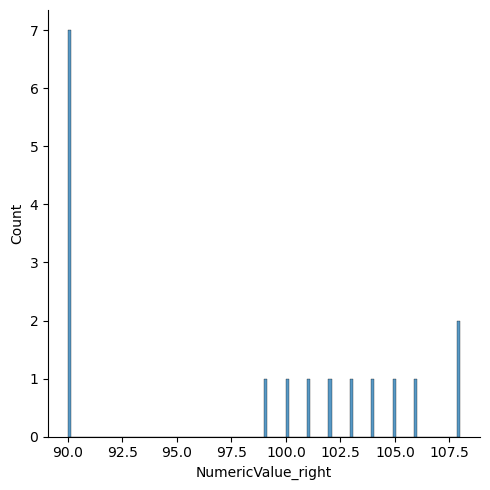

In [79]:
sns.displot(df_sample['NumericValue_right'].to_pandas(), kind='hist', bins=128)

In [26]:
df_with_neighbors = df_with_conds_pulse.filter(
    pl.col("Event_Grouper")=="Pulse"
).with_columns(
    is_any_outlier = (
            # pl.col("is_range_outlier") |
             pl.col("is_transition_outlier")
            | pl.col("is_statistical_outlier").fill_null(False) 
           )
).with_columns(
        prev_3 = pl.col("NumericValue").shift(3).over("EncounterEpicCsn"),
        prev_2 = pl.col("NumericValue").shift(2).over("EncounterEpicCsn"),
        prev_1 = pl.col("NumericValue").shift(1).over("EncounterEpicCsn"),
        next_1 = pl.col("NumericValue").shift(-1).over("EncounterEpicCsn"),
        next_2 = pl.col("NumericValue").shift(-2).over("EncounterEpicCsn"),
        next_3 = pl.col("NumericValue").shift(-3).over("EncounterEpicCsn"),
)

outliers_with_context = (
    df_with_neighbors
    .filter(pl.col("is_any_outlier"))
    .drop_nulls(subset=["prev_3", "prev_2", "prev_1", "next_1", "next_2", "next_3"])
)

In [27]:
outliers_with_context

EncounterEpicCsn,Event_Grouper,Event_DateTime,NumericValue,max_velocity_per_min,max_absolute_step,validity_window_min,upper_physiological_bound,lower_physiological_bound,prev_Event_DateTime,prev_NumericValue,delta_time,delta_value,velocity,abs_step,abs_velocity,within_window,velocity_violation,step_violation,is_transition_outlier,rolling_median,rolling_std_floored,z_score,is_statistical_outlier,is_any_outlier,prev_3,prev_2,prev_1,next_1,next_2,next_3
i64,str,datetime[μs],f64,f64,f64,i64,f64,f64,datetime[μs],f64,f64,f64,f64,f64,f64,bool,bool,bool,bool,f64,f64,f64,bool,bool,f64,f64,f64,f64,f64,f64
699476058,"""Pulse""",2024-05-01 01:19:00,90.0,60.0,150.0,30,250.0,20.0,2024-05-01 01:19:00,89.0,0.0,1.0,1e6,1.0,1e6,true,true,false,true,92.0,4.0,-0.75,false,true,90.0,90.0,89.0,90.0,90.0,90.0
699476058,"""Pulse""",2024-05-01 07:00:00,108.0,60.0,150.0,30,250.0,20.0,2024-05-01 06:00:00,90.0,60.0,18.0,0.3,18.0,0.3,false,false,false,false,90.0,4.0,4.5,true,true,90.0,90.0,90.0,108.0,106.0,104.0
699476058,"""Pulse""",2024-05-03 01:00:00,129.0,60.0,150.0,30,250.0,20.0,2024-05-03 00:45:00,107.0,15.0,22.0,1.466667,22.0,1.466667,true,false,false,false,104.0,4.0,6.25,true,true,102.0,103.0,107.0,124.0,105.0,99.0
699476058,"""Pulse""",2024-05-04 12:24:00,114.0,60.0,150.0,30,250.0,20.0,2024-05-04 12:24:00,113.0,0.0,1.0,1e6,1.0,1e6,true,true,false,true,117.0,4.0,-1.0,false,true,115.0,115.0,113.0,110.0,113.0,111.0
699476058,"""Pulse""",2024-05-04 12:50:00,113.0,60.0,150.0,30,250.0,20.0,2024-05-04 12:50:00,110.0,0.0,3.0,3e6,3.0,3e6,true,true,false,true,117.0,4.0,-1.75,false,true,113.0,114.0,110.0,111.0,113.0,113.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
747311714,"""Pulse""",2026-02-25 22:40:00,102.0,60.0,150.0,30,250.0,20.0,2026-02-25 22:40:00,101.0,0.0,1.0,1e6,1.0,1e6,true,true,false,true,80.0,4.307418,4.875311,true,true,83.0,83.0,101.0,95.0,95.0,95.0
747311714,"""Pulse""",2026-02-25 23:50:00,87.0,60.0,150.0,30,250.0,20.0,2026-02-25 23:50:00,86.0,0.0,1.0,1e6,1.0,1e6,true,true,false,true,87.0,6.293794,-0.158887,false,true,87.0,87.0,86.0,86.0,87.0,88.0
747311714,"""Pulse""",2026-02-25 23:55:00,88.0,60.0,150.0,30,250.0,20.0,2026-02-25 23:55:00,87.0,0.0,1.0,1e6,1.0,1e6,true,true,false,true,87.0,6.169153,0.0,false,true,87.0,86.0,87.0,90.0,89.0,90.0


In [29]:
summary = outliers_with_context.select([
    pl.col("prev_3").mean().alias("mean_prev_3"),
    pl.col("prev_2").mean().alias("mean_prev_2"),
    pl.col("prev_1").mean().alias("mean_prev_1"),
    pl.col("NumericValue").mean().alias("mean_outlier"),
    pl.col("next_1").mean().alias("mean_next_1"),
    pl.col("next_2").mean().alias("mean_next_2"),
    pl.col("next_3").mean().alias("mean_next_3"),
])

In [30]:
summary

mean_prev_3,mean_prev_2,mean_prev_1,mean_outlier,mean_next_1,mean_next_2,mean_next_3
f64,f64,f64,f64,f64,f64,f64
91.870097,91.96533,92.233628,95.07964,93.631042,93.171792,92.787643


In [31]:
outliers_with_deviation = outliers_with_context.with_columns(
    local_context_mean = (
        pl.col("prev_3") + pl.col("prev_2") + pl.col("prev_1")
        + pl.col("next_1") + pl.col("next_2") + pl.col("next_3")
    ) / 6,
).with_columns(
    deviation_from_context = pl.col("NumericValue") - pl.col("local_context_mean")
)

# Now look at the distribution of deviations
print(outliers_with_deviation.select("deviation_from_context").describe())

shape: (9, 2)
┌────────────┬────────────────────────┐
│ statistic  ┆ deviation_from_context │
│ ---        ┆ ---                    │
│ str        ┆ f64                    │
╞════════════╪════════════════════════╡
│ count      ┆ 59706.0                │
│ null_count ┆ 0.0                    │
│ mean       ┆ 2.469718               │
│ std        ┆ 16.450073              │
│ min        ┆ -164.333333            │
│ 25%        ┆ -3.666667              │
│ 50%        ┆ 1.0                    │
│ 75%        ┆ 10.0                   │
│ max        ┆ 186.666667             │
└────────────┴────────────────────────┘


In [36]:
asymmetry = outliers_with_context.with_columns(
    mean_before = (pl.col("prev_3") + pl.col("prev_2") + pl.col("prev_1")) / 3,
    mean_after  = (pl.col("next_1") + pl.col("next_2") + pl.col("next_3")) / 3,
).with_columns(
    before_after_diff = pl.col("mean_after") - pl.col("mean_before")
)

asymmetry_by_layer = asymmetry.group_by([
   "is_transition_outlier", "is_statistical_outlier"
]).agg([
    pl.col("before_after_diff").mean().alias("mean_diff"),
    pl.col("before_after_diff").median().alias("median_diff"),
    pl.col("before_after_diff").std().alias("std_diff"),
    pl.len().alias("n"),
])

asymmetry_by_layer

is_transition_outlier,is_statistical_outlier,mean_diff,median_diff,std_diff,n
bool,bool,f64,f64,f64,u64
true,true,2.411863,1.666667,15.094783,798
true,false,-0.489114,-0.666667,7.691515,31523
true,null,0.438833,0.5,34.134175,594
false,true,3.109863,3.0,17.271037,26791


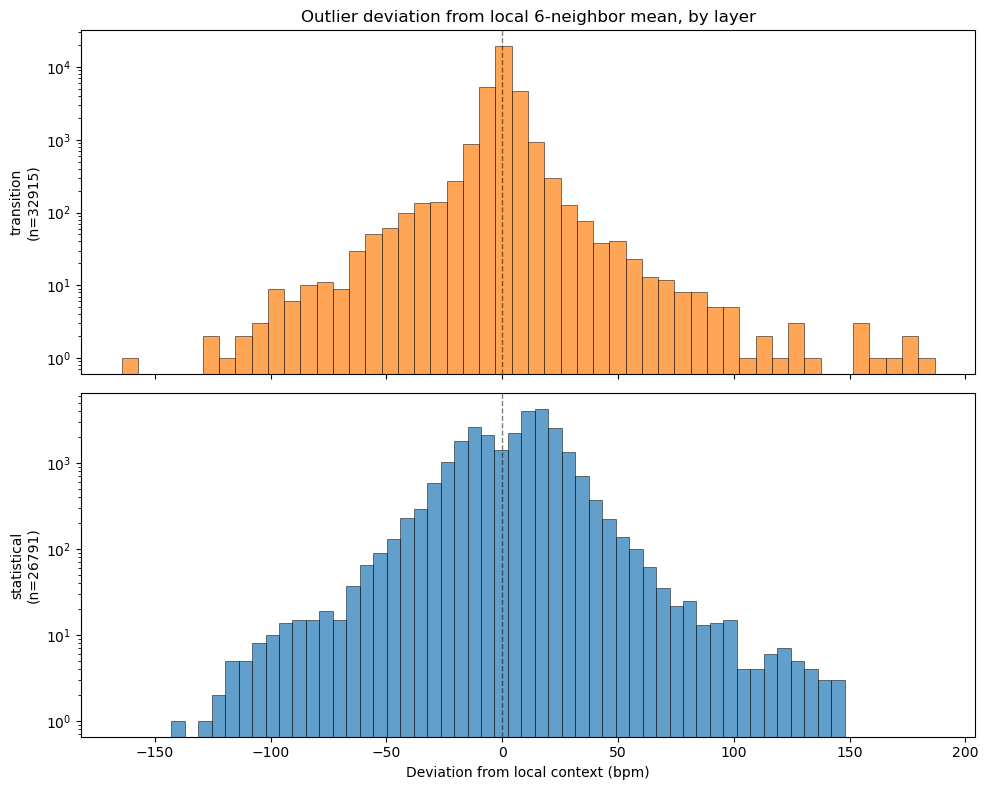

In [39]:
import matplotlib.pyplot as plt

# Build per-layer subsets ? a row can be flagged by multiple layers; for clarity,
# use mutually exclusive categories: which is the "first" layer that flagged it?
# (Ordering: range > transition > statistical, since range is the most fundamental.)
plot_data = outliers_with_deviation.with_columns(
    # layer = pl.when(pl.col("is_range_outlier")).then(pl.lit("range"))
    layer = pl.when(pl.col("is_transition_outlier")).then(pl.lit("transition"))
            .when(pl.col("is_statistical_outlier").fill_null(False)).then(pl.lit("statistical"))
            .otherwise(pl.lit("none"))
).filter(pl.col("layer") != "none")

# Convert to pandas for easier matplotlib interop ? small frame, this is fine
pd_data = plot_data.select(["layer", "deviation_from_context"]).to_pandas()

# fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
# layers = ["range", "transition", "statistical"]
# colors = ["#d62728", "#ff7f0e", "#1f77b4"]  # red, orange, blue

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
layers = [ "transition", "statistical"]
colors = [ "#ff7f0e", "#1f77b4"]  # red, orange, blue

for ax, layer, color in zip(axes, layers, colors):
    subset = pd_data[pd_data["layer"] == layer]["deviation_from_context"]
    ax.hist(subset, bins=50, color=color, alpha=0.7, edgecolor="black", linewidth=0.5)
    ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)
    ax.set_ylabel(f"{layer}\n(n={len(subset)})")
    ax.set_yscale("log")  # see the tails

axes[-1].set_xlabel("Deviation from local context (bpm)")
axes[0].set_title("Outlier deviation from local 6-neighbor mean, by layer")
plt.tight_layout()
plt.show()

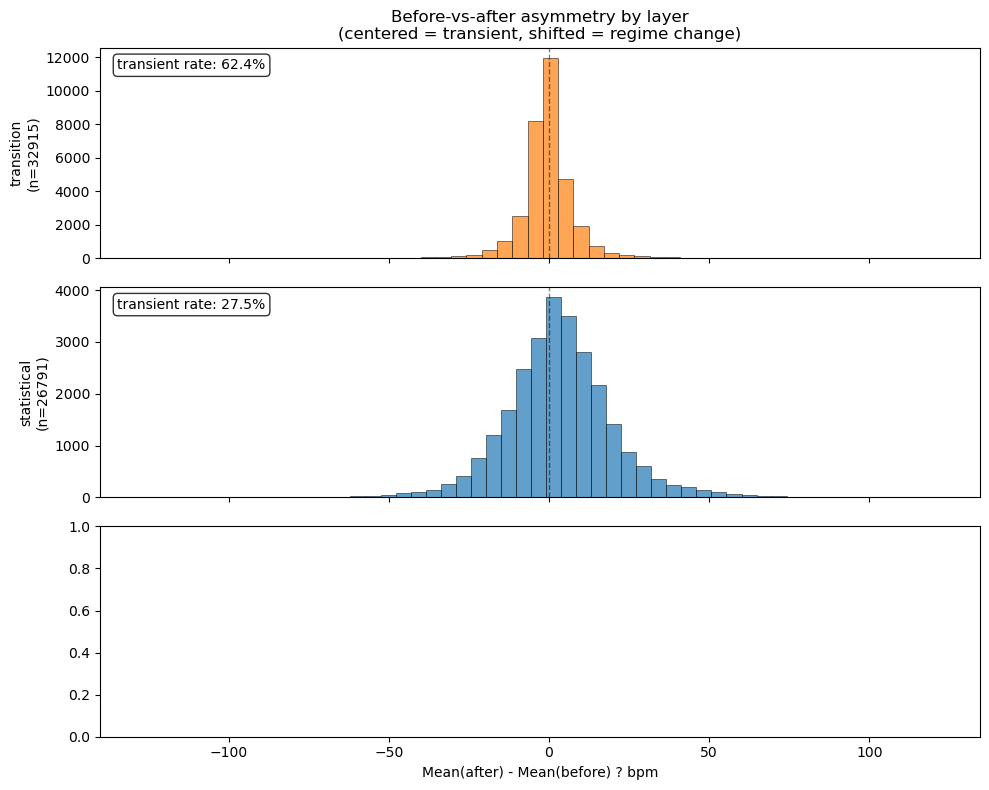

In [40]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Compute before_after_diff if not already in the frame
plot_data2 = plot_data.with_columns(
    mean_before = (pl.col("prev_3") + pl.col("prev_2") + pl.col("prev_1")) / 3,
    mean_after  = (pl.col("next_1") + pl.col("next_2") + pl.col("next_3")) / 3,
).with_columns(
    before_after_diff = pl.col("mean_after") - pl.col("mean_before")
)

pd_data2 = plot_data2.select(["layer", "before_after_diff"]).to_pandas()

TRANSIENT_THRESHOLD = 5  # bpm; tune for your vital

for ax, layer, color in zip(axes, layers, colors):
    subset = pd_data2[pd_data2["layer"] == layer]["before_after_diff"]
    ax.hist(subset, bins=50, color=color, alpha=0.7, edgecolor="black", linewidth=0.5)
    ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)
    
    # Compute and annotate the transient rate
    transient_rate = (subset.abs() < TRANSIENT_THRESHOLD).mean()
    ax.text(0.02, 0.95, f"transient rate: {transient_rate:.1%}", 
            transform=ax.transAxes, verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    
    ax.set_ylabel(f"{layer}\n(n={len(subset)})")

axes[-1].set_xlabel("Mean(after) - Mean(before) ? bpm")
axes[0].set_title("Before-vs-after asymmetry by layer\n(centered = transient, shifted = regime change)")
plt.tight_layout()
plt.show()

No outliers for layer range
728343856
729151053
740124054
725186139
730837832
738254691
738626935
722702008
746279777


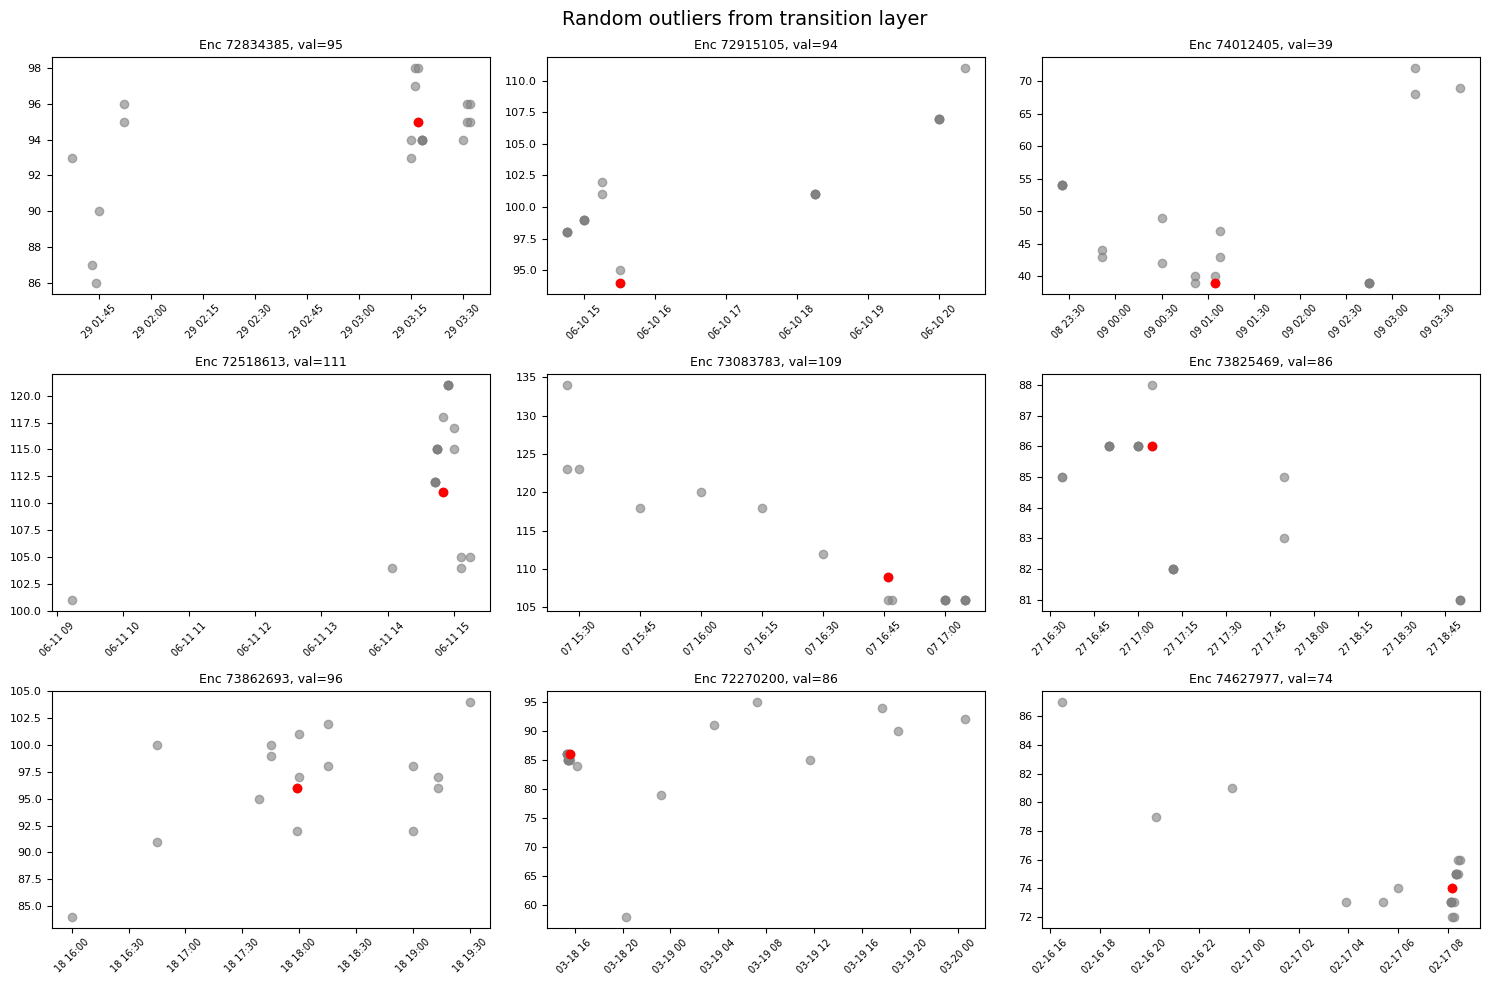

729914418
714534044
733134566
716208986
746368136
725637311
733704050
728086896
727676542


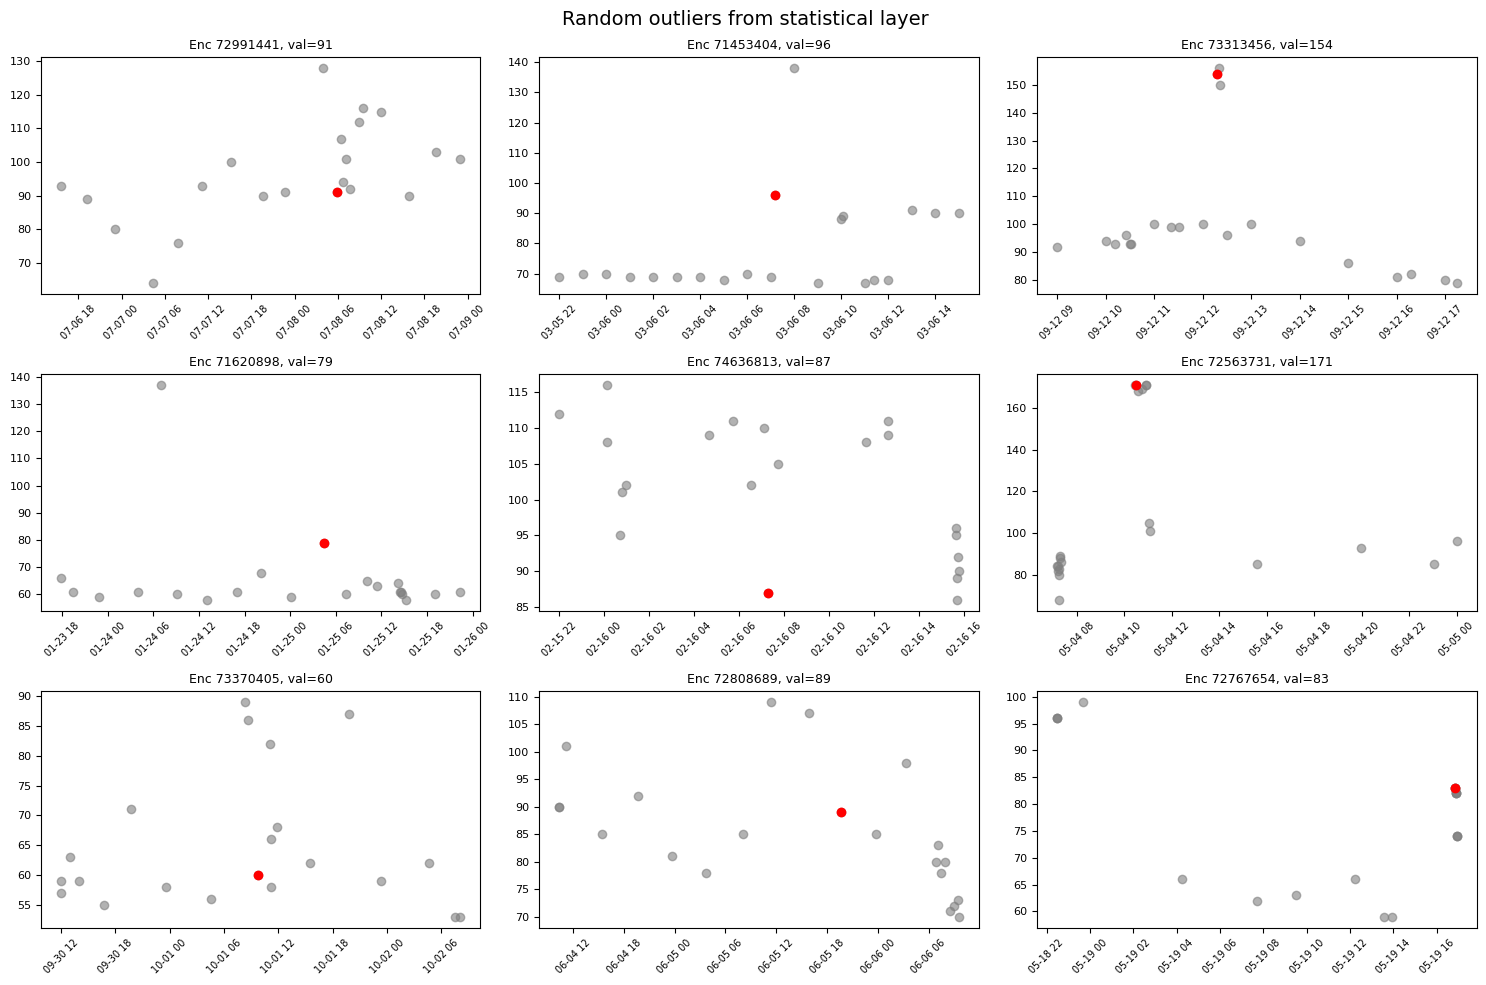

In [58]:
import numpy as np
np.random.seed(42)  # reproducible

CONTEXT_READINGS = 10  # show ±10 readings around the flagged point

def plot_layer_examples(plot_data_full, df_pulse_full, layer_name, n_examples=9):
    """Plot a 3x3 grid of randomly-sampled outliers from a given layer."""
    layer_outliers = plot_data_full.filter(pl.col("layer") == layer_name)
    
    if layer_outliers.height == 0:
        print(f"No outliers for layer {layer_name}")
        return
    
    # Sample random row indices from this layer's outliers
    sample_size = min(n_examples, layer_outliers.height)
    sample_idx = np.random.choice(layer_outliers.height, sample_size, replace=False)
    sampled = layer_outliers[sample_idx]
    
    fig, axes = plt.subplots(3, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for ax, row in zip(axes, sampled.iter_rows(named=True)):
        encounter = row["EncounterEpicCsn"]
        print(encounter)
        outlier_time = row["Event_DateTime"]
        outlier_value = row["NumericValue"]
        
        # Pull the encounter's full pulse data, find context window
        encounter_data = (
            df_pulse_full
            .filter( (pl.col("EncounterEpicCsn") == encounter) &
                    (pl.col("Event_Grouper") == row["Event_Grouper"])  # add this
            )

            .sort(by="Event_DateTime")
        )
        
        # Find the index of the outlier in this encounter's series
        all_times = encounter_data["Event_DateTime"].to_list()
        outlier_idx = all_times.index(outlier_time)
        
        start = max(0, outlier_idx - CONTEXT_READINGS)
        end = min(encounter_data.height, outlier_idx + CONTEXT_READINGS + 1)
        context = encounter_data[start:end]
        
        times = context["Event_DateTime"].to_list()
        values = context["NumericValue"].to_list()
        
        # ax.plot(times, values, "o-", color="gray", alpha=0.6, markersize=4)
        # ax.plot([outlier_time], [outlier_value], "o", color="red", markersize=10, 
        #         markeredgecolor="black", zorder=5)

        ax.scatter(times, values, color="gray", alpha=0.6, )
        ax.scatter([outlier_time], [outlier_value], color="red",  
                zorder=5)
        ax.set_title(f"Enc {str(encounter)[:8]}, val={outlier_value:.0f}", fontsize=9)
        ax.tick_params(axis="x", rotation=45, labelsize=7)
        ax.tick_params(axis="y", labelsize=8)
    
    fig.suptitle(f"Random outliers from {layer_name} layer", fontsize=14)
    plt.tight_layout()
    plt.show()


# Run for each layer
for layer in ["range", "transition", "statistical"]:
    plot_layer_examples(plot_data, df_with_conds_pulse.filter(pl.col("Event_Grouper")=='Pulse'), layer)

In [57]:
df_with_conds_pulse.filter(pl.col("EncounterEpicCsn")==728343856)

EncounterEpicCsn,Event_Grouper,Event_DateTime,NumericValue,max_velocity_per_min,max_absolute_step,validity_window_min,upper_physiological_bound,lower_physiological_bound,prev_Event_DateTime,prev_NumericValue,delta_time,delta_value,velocity,abs_step,abs_velocity,within_window,velocity_violation,step_violation,is_transition_outlier,rolling_median,rolling_std_floored,z_score,is_statistical_outlier
i64,str,datetime[μs],f64,f64,f64,i64,f64,f64,datetime[μs],f64,f64,f64,f64,f64,f64,bool,bool,bool,bool,f64,f64,f64,bool
728343856,"""Respirations""",2025-05-28 20:36:00,24.0,20.0,30.0,30,60.0,4.0,2025-05-28 20:26:00,17.0,10.0,7.0,0.7,7.0,0.7,true,false,false,false,null,null,null,null
728343856,"""Pulse""",2025-05-28 20:36:00,104.0,60.0,150.0,30,250.0,20.0,2025-05-28 20:26:00,106.0,10.0,-2.0,-0.2,2.0,0.2,true,false,false,false,null,4.0,null,null
728343856,"""Blood Pressure""",2025-05-28 20:37:00,140.0,60.0,100.0,30,300.0,40.0,2025-05-28 20:26:00,124.0,11.0,16.0,1.454545,16.0,1.454545,true,false,false,false,null,null,null,null
728343856,"""Respirations""",2025-05-28 20:37:00,25.0,20.0,30.0,30,60.0,4.0,2025-05-28 20:36:00,24.0,1.0,1.0,0.999999,1.0,0.999999,true,false,false,false,null,null,null,null
728343856,"""Pulse""",2025-05-28 20:37:00,107.0,60.0,150.0,30,250.0,20.0,2025-05-28 20:36:00,104.0,1.0,3.0,2.999997,3.0,2.999997,true,false,false,false,104.0,4.0,0.75,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
728343856,"""Blood Pressure""",2025-06-06 10:45:00,96.0,60.0,100.0,30,300.0,40.0,2025-06-06 10:30:00,95.0,15.0,1.0,0.066667,1.0,0.066667,true,false,false,false,null,null,null,null
728343856,"""Respirations""",2025-06-06 11:00:00,25.0,20.0,30.0,30,60.0,4.0,2025-06-06 10:45:00,25.0,15.0,0.0,0.0,0.0,0.0,true,false,false,false,null,null,null,null
728343856,"""Pulse""",2025-06-06 11:00:00,86.0,60.0,150.0,30,250.0,20.0,2025-06-06 10:45:00,107.0,15.0,-21.0,-1.4,21.0,1.4,true,false,false,false,119.0,6.323096,-5.218963,true


In [53]:
enc = 72808689
df_with_conds_pulse.filter(
    pl.col("EncounterEpicCsn") == enc
).sort("Event_DateTime").select([
    "Event_DateTime", "Event_Grouper", "NumericValue"
]).head(30)

Event_DateTime,Event_Grouper,NumericValue
datetime[μs],str,f64


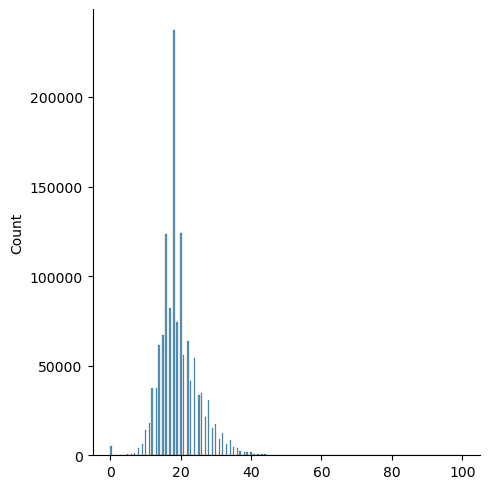

In [8]:
# for v in ['Temperature', "Pulse", "Respirations", "Blood Pressure"]:
all_resp_vals = df_all.filter(
	(pl.col("Type") == "Flowsheet")&
	(pl.col("Event_Grouper") == "Respirations")
)['NumericValue'].to_numpy()


sns.displot(all_resp_vals,  kind='hist', bins=256)